In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [61]:
pd.set_option("display.max_columns",100)
pd.set_option("display.max_rows",100)

In [62]:
df=pd.read_csv('marketing_campaign.csv',sep='\t')

In [63]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [64]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [65]:
df.shape

(2240, 29)

In [66]:
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0


In [67]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [68]:
#check null 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

#Exploration of data

In [69]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [70]:
#convert datetie column to datetime format
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],format='%d-%m-%Y')

In [71]:
df['Dt_Customer']

0      2012-09-04
1      2014-03-08
2      2013-08-21
3      2014-02-10
4      2014-01-19
          ...    
2235   2013-06-13
2236   2014-06-10
2237   2014-01-25
2238   2014-01-24
2239   2012-10-15
Name: Dt_Customer, Length: 2240, dtype: datetime64[ns]

In [72]:
#now drop 'ID' column and spearating object and categorical column data types
columns=[column for column in df.columns if column!='ID']



In [73]:
#separate niumerical and categorical datatypes

numeric_features=[feature for feature in columns if df[feature].dtype != 'O']
categorical_features=[feature for feature in columns if df[feature].dtype == 'O']

#peint columns
print(f"there are {(len(numeric_features))} numerical features : {numeric_features}")
print(f"there are {(len(categorical_features))} categorical features : {categorical_features}")

there are 26 numerical features : ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
there are 2 categorical features : ['Education', 'Marital_Status']


### Feature Information

- **People**

    - **ID:** Customer's unique identifier
    - **Year_Birth:** Customer's birth year
    - **Education:** Customer's education level
    - **Marital_Status:** Customer's marital status
    - **Income:** Customer's yearly household income
    - **Kidhome:** Number of children in customer's household
    - **Teenhome:** Number of teenagers in customer's household
    - **Dt_Customer:** Date of customer's enrollment with the company
    - **Recency:** Number of days since customer's last purchase
    - **Complain:** 1 if the customer complained in the last 2 years, 0 otherwise

- **Products**

    - **MntWines:** Amount spent on wine in last 2 years
    - **MntFruits:** Amount spent on fruits in last 2 years
    - **MntMeatProducts:** Amount spent on meat in last 2 years
    - **MntFishProducts:** Amount spent on fish in last 2 years
    - **MntSweetProducts:** Amount spent on sweets in last 2 years
    - **MntGoldProds:** Amount spent on gold in last 2 years

- **Promotion**

    - **NumDealsPurchases:** Number of purchases made with a discount
    - **AcceptedCmp1:** 1 if customer accepted the offer in the 1st campaign, 0 otherwise
    - **AcceptedCmp2:** 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
    - **AcceptedCmp3:** 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
    - **AcceptedCmp4:** 1 if customer accepted the offer in the 4th campaign, 0 otherwise
    - **AcceptedCmp5:** 1 if customer accepted the offer in the 5th campaign, 0 otherwise
    - **Response:** 1 if customer accepted the offer in the last campaign, 0 otherwise

- **Place**

    - **NumWebPurchases:** Number of purchases made through the company’s website
    - **NumCatalogPurchases:** Number of purchases made using a catalogue
    - **NumStorePurchases:** Number of purchases made directly in stores
    - **NumWebVisitsMonth:** Number of visits to company’s website in the last month

In [74]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [75]:
#unqique vales in education column
df[categorical_features[0]].value_counts().count()

5

In [76]:
df[categorical_features[0]].value_counts()

Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: Education, dtype: int64

In [77]:
#proportion count of categorical columns
for col in categorical_features:
  print(df[col].value_counts(normalize=True)* 100)
  print('--------------------')

Graduation    50.312500
PhD           21.696429
Master        16.517857
2n Cycle       9.062500
Basic          2.410714
Name: Education, dtype: float64
--------------------
Married     38.571429
Together    25.892857
Single      21.428571
Divorced    10.357143
Widow        3.437500
Alone        0.133929
Absurd       0.089286
YOLO         0.089286
Name: Marital_Status, dtype: float64
--------------------


In [78]:
df[numeric_features].dtypes

Year_Birth                      int64
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Complain                        int64
Z_CostContact                   int64
Z_Revenue                       int64
Response                        int64
dtype: objec

In [79]:
df[categorical_features].dtypes

Education         object
Marital_Status    object
dtype: object

EDA

Univariate = one variable analysis

We check:

distribution

skewness

outliers

data concentration

In [80]:
#univariate analysis

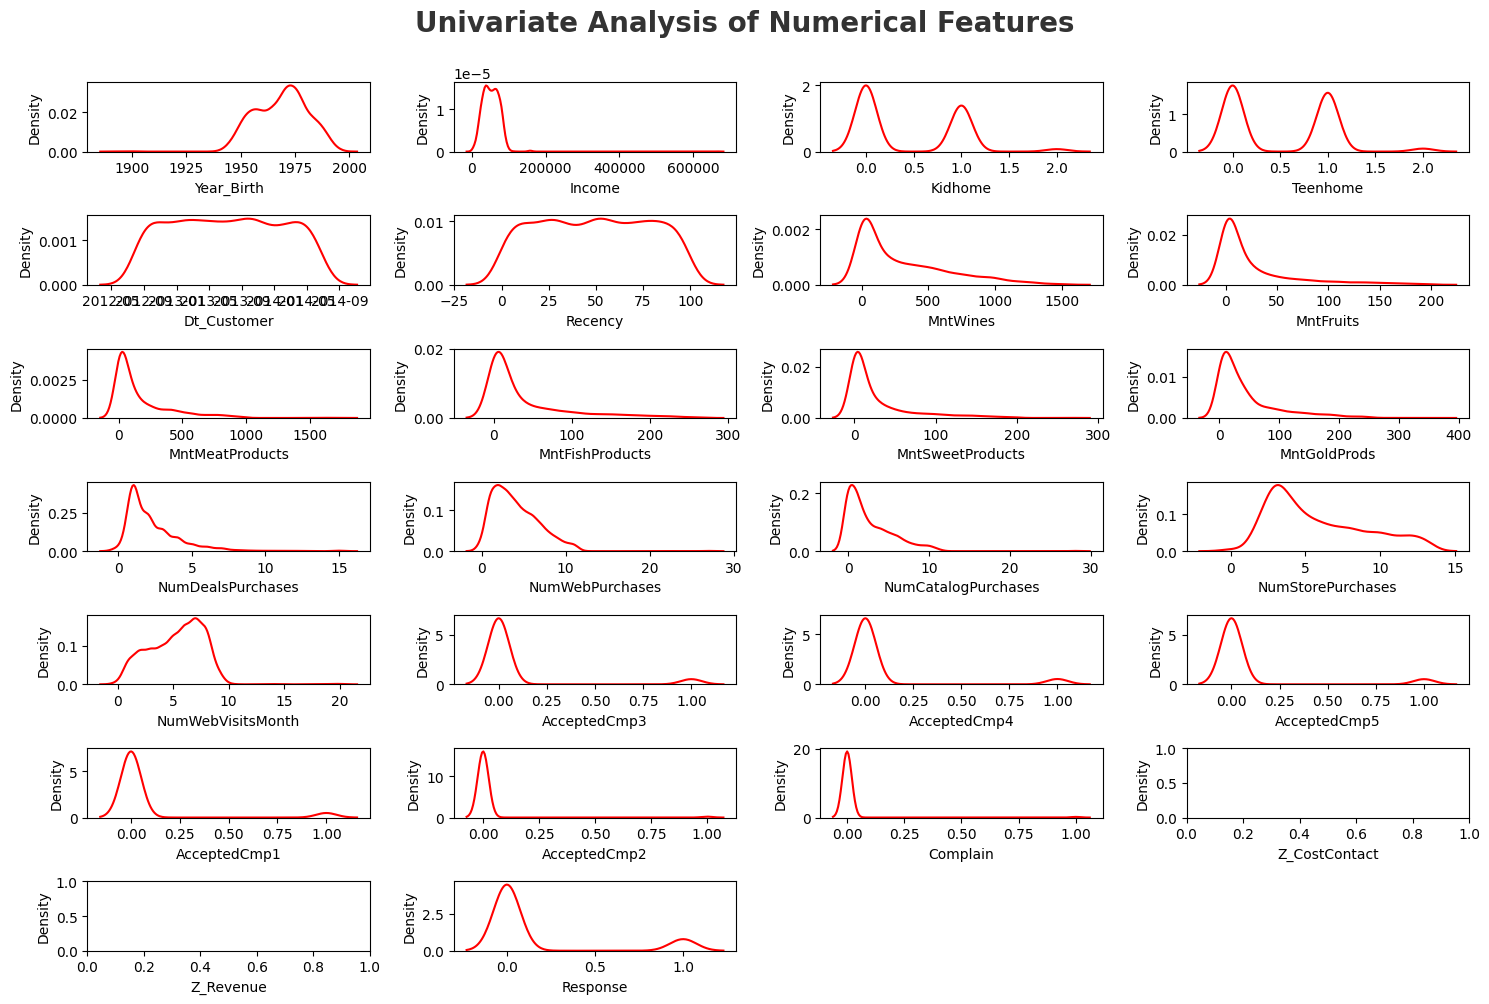

In [81]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(7, 4, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='red')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()
    
# save plot
# plt.savefig('./images/Univariate_Num.png')

*Report of the univariate analytis*
1. `Year_Birth` is left-skewed, most of the values falls in 1940-2000 range and has outliers.
2. `Income` is right-skewed, most of the values falls in 0 - <200000 range and has outliers.
3. `Kidhome`, `Teenhome` has constant values. Most of the values seems to be 0 or 1 and some of the values are 2.
4. `Dt_customer`, `Recency` are following a normal distribution
5. `MntWines`, `MntMeatProducts` are right-skewed, most of the values falls in 0 - 500 range and has outliers.
6. `MntFruits`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` is right-skewed, most of the values falls in 0-50 range and has outliers.
7. `NumDealsPurchases` is right-skewed, most of the values falls in 0-5 range and has outliers.
8. `NumWebPurchases`, `NumCatalogPurchases` are right skewed and most of the values falls in 0-10 range and have outliers.
9. `NumStorePurchases` is almost following a normal distribution and most of the values falls in 1 - 10 range and has outliers.
10. `NumWebVisitsMonth` is right-skewed, most of the values falls in 0- 10 range and has outliers.
11. `AcceptedCmp3`, `AcceptedCmp4`, `AcceptedCmp5`, `AcceptedCmp1`,`AcceptedCmp2` is right skewed and most of the values are 0 and some of the values are 1.
12. `Complain` has most of the values as 0 and we can see a little bit of the values as 1. 
13. `Z_CostContact`, `Z_Revenue` columns are not showing any graph. We'll graph those seperately and check what is happening.
14. `Response` has constant values as 0 and 1. 

<AxesSubplot:>

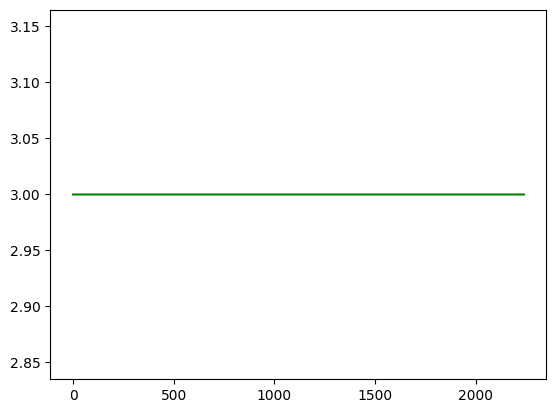

In [82]:
df['Z_CostContact'].plot(color='green')

<AxesSubplot:>

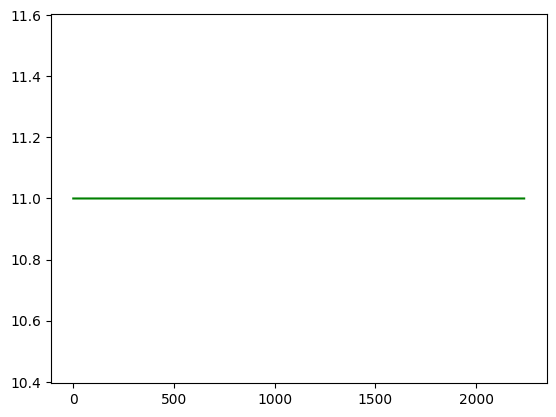

In [83]:
df['Z_Revenue'].plot(color='green')

- The column ```Z_CostContact```, ```Z_Revenue``` does have constant values. As this columns does not have any varience, we can drop this column

In [84]:
df=df.drop(columns=['Z_CostContact','Z_Revenue'])
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

- for numerical columns we have KDE plot and for categorical columns we have countplots

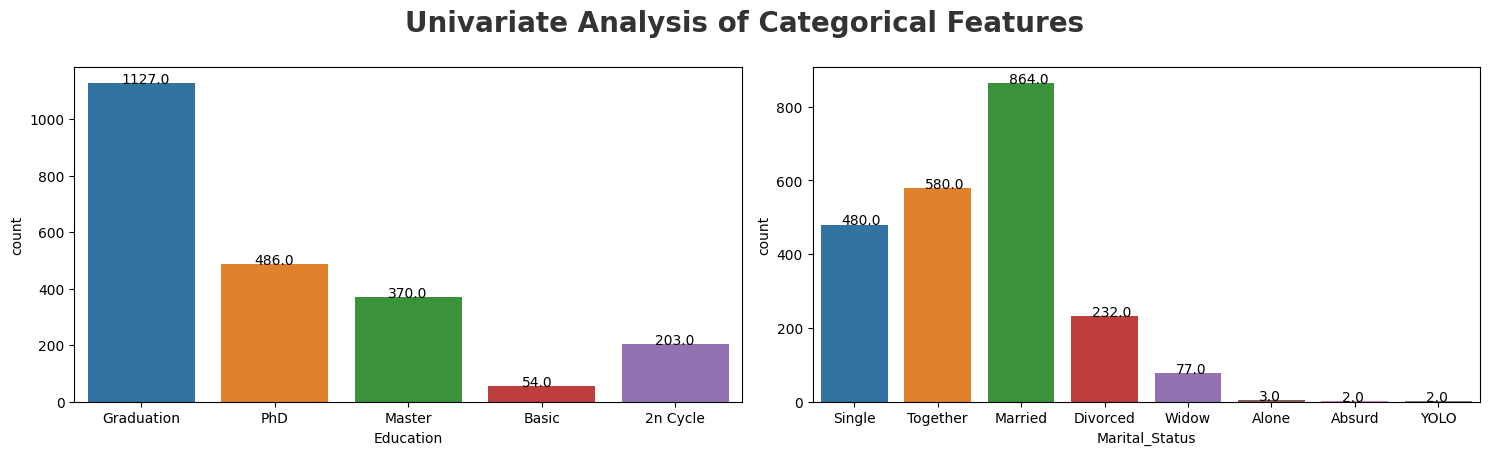

In [85]:
# categorical columns
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(2, 2, i+1)
    ax = sns.countplot(x=df[categorical_features[i]])
    if df[categorical_features[i]].value_counts().count() <10:
        for p in ax.patches:
            ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))
    plt.xlabel(categorical_features[i])
    plt.tight_layout()
    
# save plot
# plt.savefig('./images/Univariate_Cat.png')

**Report/my insights**
- For column **``Education``**
    - Most of the Customers are falling into **Graduation** category.
    - Respectively, **PhD, Master Education, Basic and *2n Cycle** are also present.
    
    _2nCycle_ -  Multidisciplinary degree programmes are second cycle degree programmes in which the teaching system meets the requirements of two different classes
    
- For column **```Maritial_Status```**
    - For about **864** customers are married. 
    - **Together, single, divorced, widow** are noticeable where **Alone, Absurd and YOLO** categories are very less.

<AxesSubplot:xlabel='YEAR', ylabel='CUSTOMER_JOINED'>

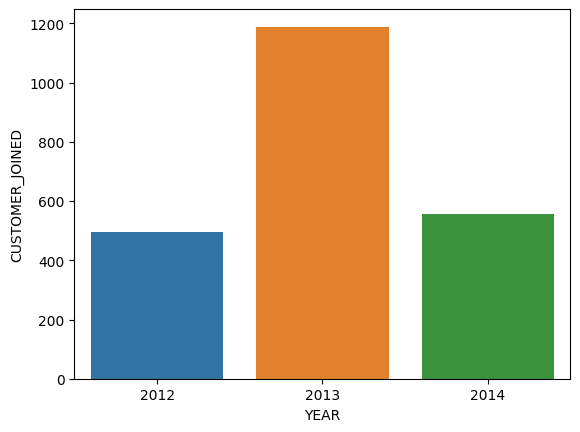

In [86]:
#Count of customer based on years

df1=df.copy()
df1['Year']=df1.Dt_Customer.dt.year #extract only year from the dattime column
customer_joined_per_year=df1.groupby(by='Year',axis=0)[['ID']].count()
customer_joined_per_year=customer_joined_per_year.reset_index()
customer_joined_per_year.columns=['YEAR','CUSTOMER_JOINED']
sns.barplot(data=customer_joined_per_year,x=customer_joined_per_year['YEAR'],y=customer_joined_per_year['CUSTOMER_JOINED'])

**Report**
- By this report, we can say that, most number of customers have joined in the year **2013**
- The number of customers got increased in year 2013 but in the year 2014, the number of customers got decreased.

## Multivariat analysis

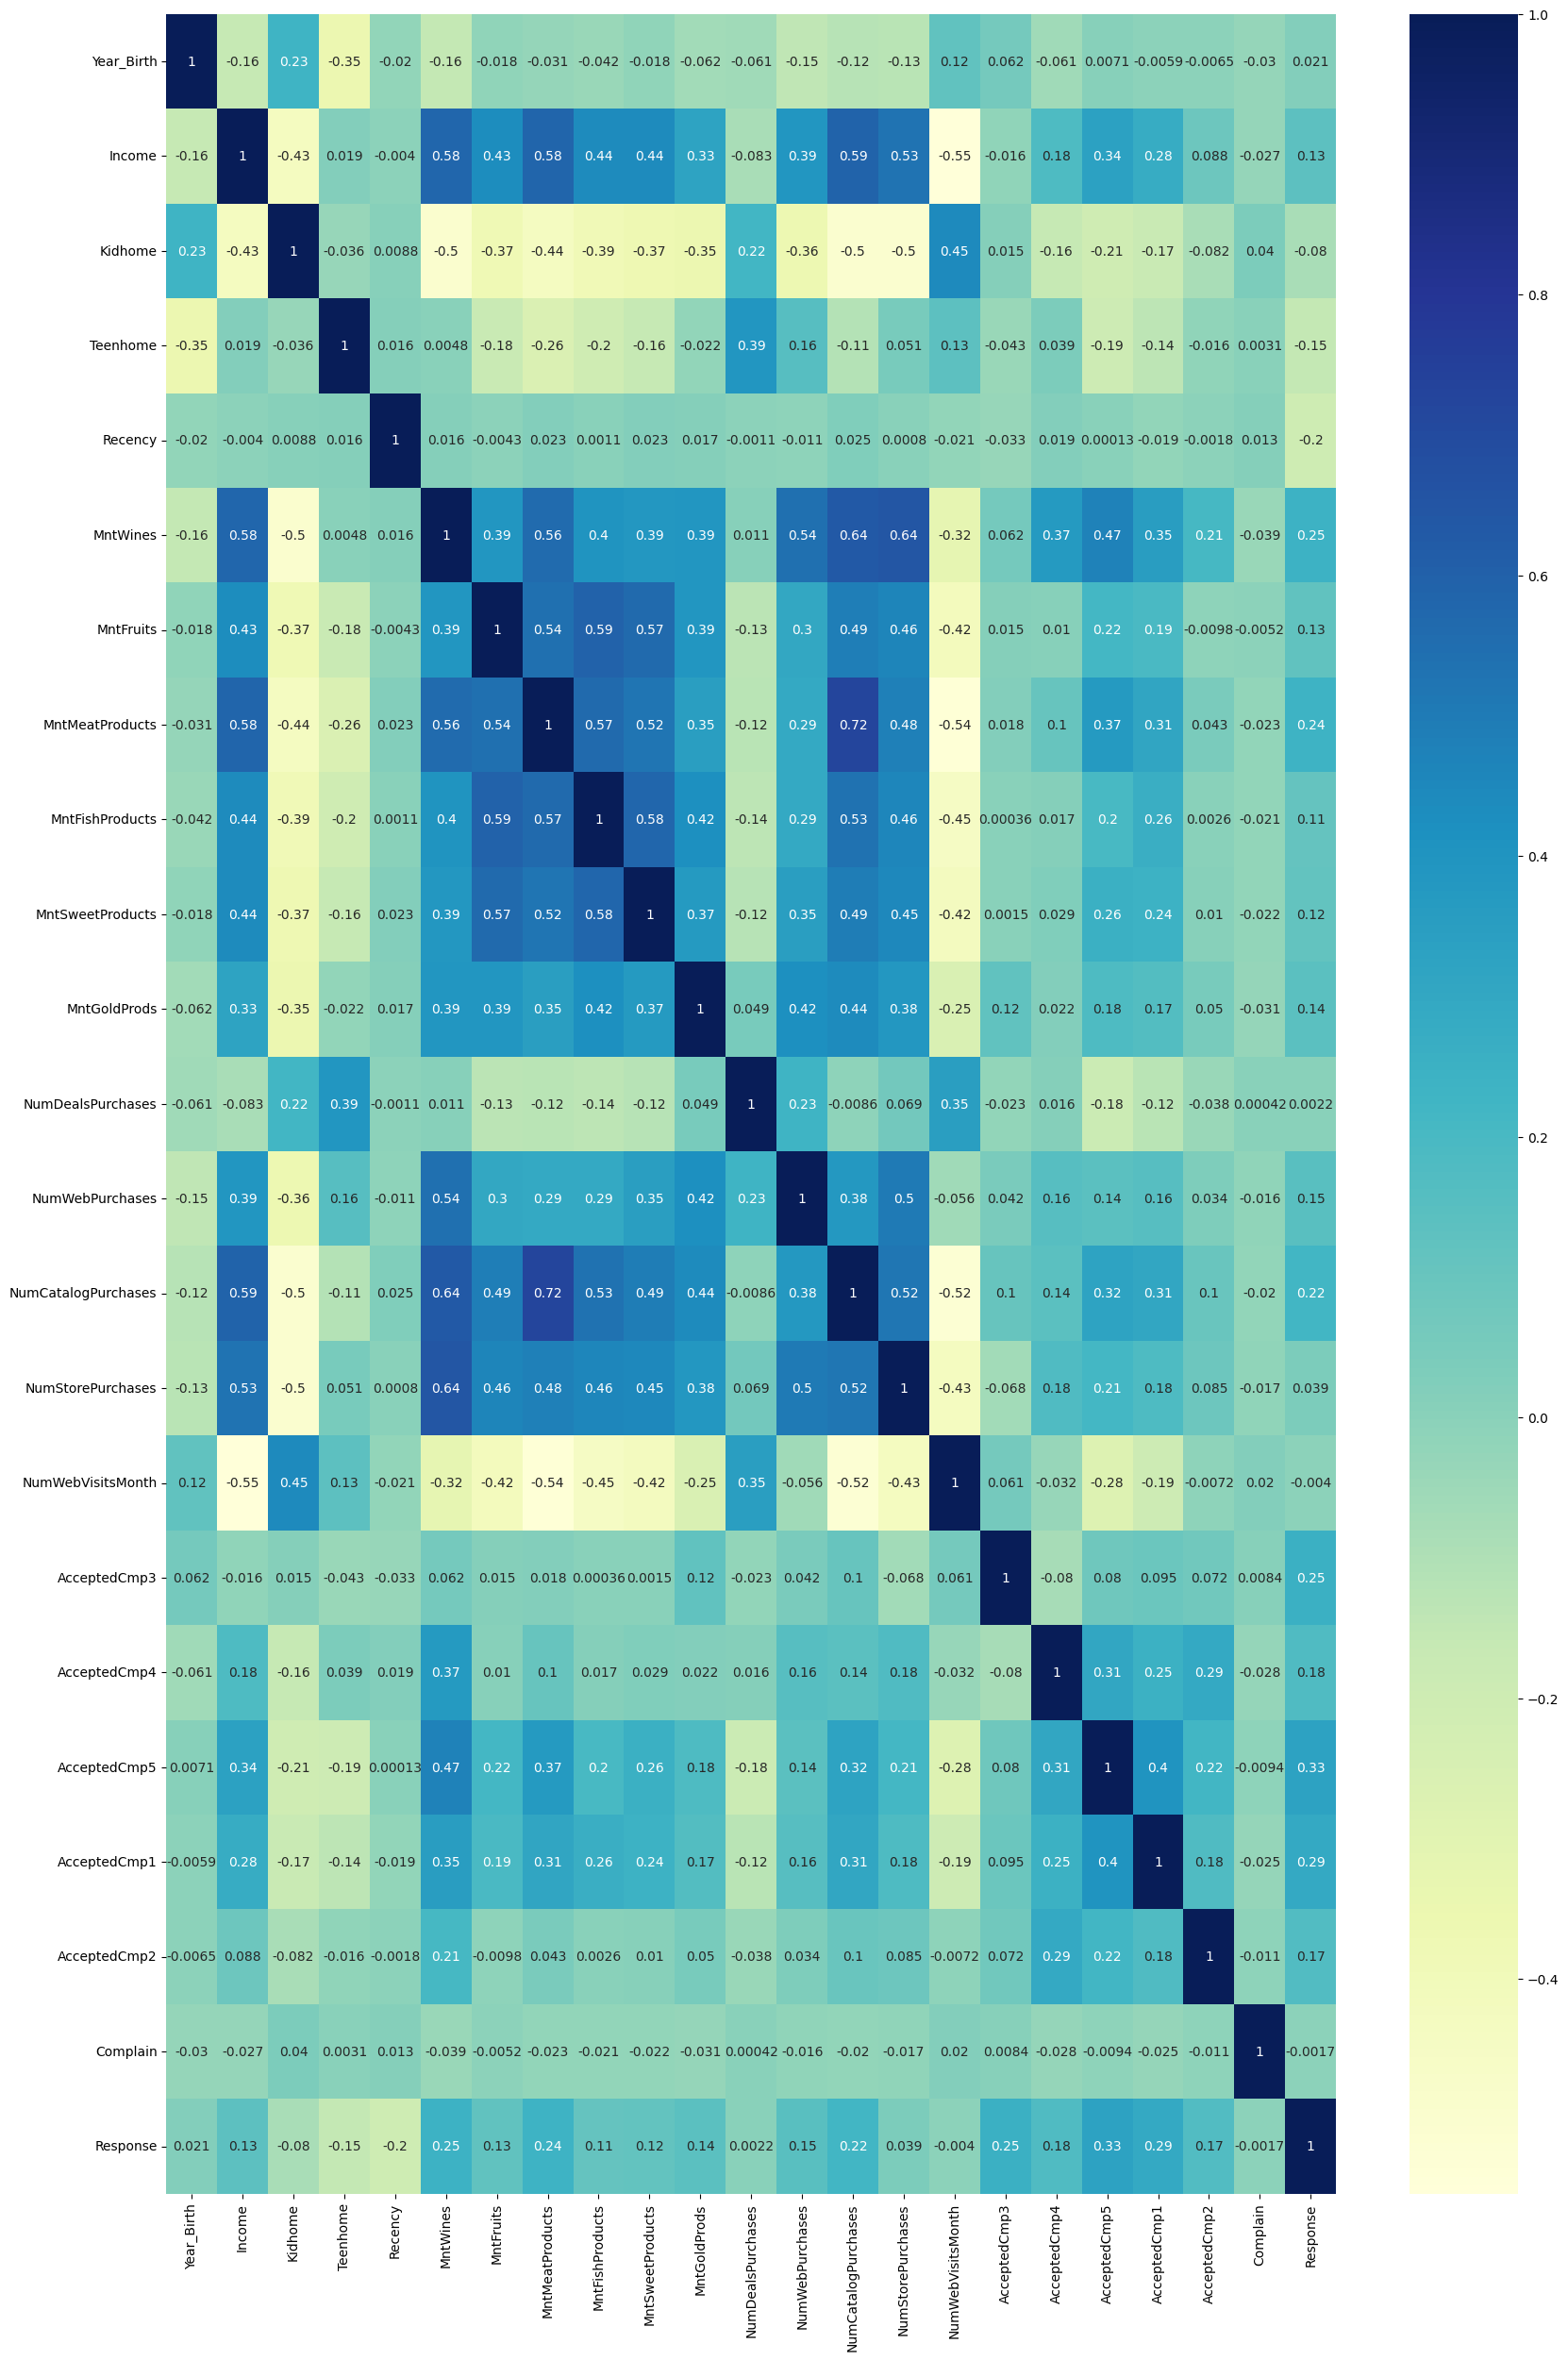

In [87]:
plt.figure(figsize=(20,30))
num_features=numeric_features.copy()
num_features.remove('Z_CostContact')
num_features.remove('Z_Revenue')

sns.heatmap(df[num_features].corr(),annot=True,cmap="YlGnBu")
plt.show()

In [88]:
#checkign and replacing Null values in income columns (doing imputation)

df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64

In [89]:
df['Income'].median()

51381.5

In [90]:
df['Income'].fillna(df['Income'].median(),inplace=True)

In [91]:
df['Income'].isnull().sum()

0

## Feature Extraction

In [92]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

In [93]:
df.shape

(2240, 27)

In [94]:
#creating features that would help describe the customer profile

from datetime import datetime

raw_df=df.copy() #saving raw dataframe incase for reference

#calcualing age
df['Age']=2025-df['Year_Birth']

#categorical encoding 
df['Education']=df['Education'].replace({'Basic':0,'2n Cycle':1,'Graduation':2,'Master':3,'PhD':4})
df['Marital_Status']=df['Marital_Status'].replace({'Married':1,'Together':1,'Absurd':0,'Widow':0,'YOLO':0,'Divorced':0,'Single':0,'Alone':0})

#creating a new field to store the number of children in household
df['Children']=df['Kidhome']+df['Teenhome']

#crearing family size (wife/husband if any + children if any + customer himself/herself )
df['Family_Size']=df['Marital_Status']+df['Children']+1

#total spending of the customer

df['Total_Spending']=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

df['Total_Promo']=df['AcceptedCmp1']+df['AcceptedCmp2']+df['AcceptedCmp3']+df['AcceptedCmp4']+df['AcceptedCmp5']



#calcualte for how long customer has remained attached with the company and the total number of promotions to whuch the customers responded to

df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'])
today=datetime.today()
df['Days_as_Customer']=(today-df['Dt_Customer']).dt.days
df['Offers_Responded_To']=df['AcceptedCmp1']+df['AcceptedCmp2']+df['AcceptedCmp3']+df['AcceptedCmp4']+df['AcceptedCmp5']+df['Response']
df["Parental Status"] = np.where(df["Children"] > 0, 1, 0)


#dropping columns which are already used to create new features
columns_to_drop = ['Year_Birth','Kidhome','Teenhome']
df.drop(columns = columns_to_drop, axis = 1, inplace=True)
df.rename(columns={"Marital_Status": "Marital Status","MntWines": "Wines","MntFruits":"Fruits",
                   "MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets",
                   "MntGoldProds":"Gold","NumWebPurchases": "Web","NumCatalogPurchases":"Catalog",
                   "NumStorePurchases":"Store","NumDealsPurchases":"Discount Purchases","Total_Promo": "Total Promo"},
          inplace = True)

df = df[["Age","Education","Marital Status","Parental Status","Children","Income","Total_Spending","Days_as_Customer","Recency","Wines","Fruits","Meat","Fish","Sweets","Gold","Web","Catalog","Store","Discount Purchases","Total Promo","NumWebVisitsMonth"]]




In [95]:
df.shape

(2240, 21)

In [96]:
df.head()

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
0,68,2,0,0,0,58138.0,1617,4933,58,635,88,546,172,88,88,8,10,4,3,0,7
1,71,2,0,1,2,46344.0,27,4383,38,11,1,6,2,1,6,1,1,2,2,0,5
2,60,2,1,0,0,71613.0,776,4582,26,426,49,127,111,21,42,8,2,10,1,0,4
3,41,2,1,1,1,26646.0,53,4409,26,11,4,20,10,3,5,2,0,4,2,0,6
4,44,4,1,1,1,58293.0,422,4431,94,173,43,118,46,27,15,5,3,6,5,0,5


In [98]:
df.isna().sum()

Age                   0
Education             0
Marital Status        0
Parental Status       0
Children              0
Income                0
Total_Spending        0
Days_as_Customer      0
Recency               0
Wines                 0
Fruits                0
Meat                  0
Fish                  0
Sweets                0
Gold                  0
Web                   0
Catalog               0
Store                 0
Discount Purchases    0
Total Promo           0
NumWebVisitsMonth     0
dtype: int64

In [99]:
columns = [column for column in df.columns if column != "ID"]

numeric_features = [feature for feature in columns if df[feature].dtype != 'O']

continuous_features=[feature for feature in numeric_features if len(df[feature].unique())>=10]
print('Names of continues features :',continuous_features)

Names of continues features : ['Age', 'Income', 'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Catalog', 'Store', 'Discount Purchases', 'NumWebVisitsMonth']


### Multicollinearity Check
#### Variance Inflation Factor (VIF)
* Multicollinearity occurs when there are two or more independent variables in a multiple regression model, which have a high correlation among themselves. When some features are highly correlated.
* Multicollinearity can be detected using various techniques, one such technique being the Variance Inflation Factor(VIF).

In [100]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def compute_vif(considered_features, df):
    
    X = df[considered_features]
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

        
#we will remove the datetime column which is not required for the vif checking
cont_features = continuous_features.copy()

# we will not chech vif for total spending, as it is the summation of Wines,Fruits,Meat,Fish,Sweets,Gold.
cont_features.remove('Total_Spending')
compute_vif(cont_features, df)
# other_columns

,Variable,VIF
0,Age,1.075265
1,Income,2.125893
2,Days_as_Customer,1.275059
3,Recency,1.004938
4,Wines,2.642362
5,Fruits,1.933450
6,Meat,2.757364
7,Fish,2.068554
8,Sweets,1.898322
9,Gold,1.484205


#### Most research papers consider a VIF (Variance Inflation Factor) > 10 as an indicator of multicollinearity, but some choose a more conservative threshold of 5.
**As we can see the Vif for the columns are less than 5, we can safely assume that the data has not such correlations.

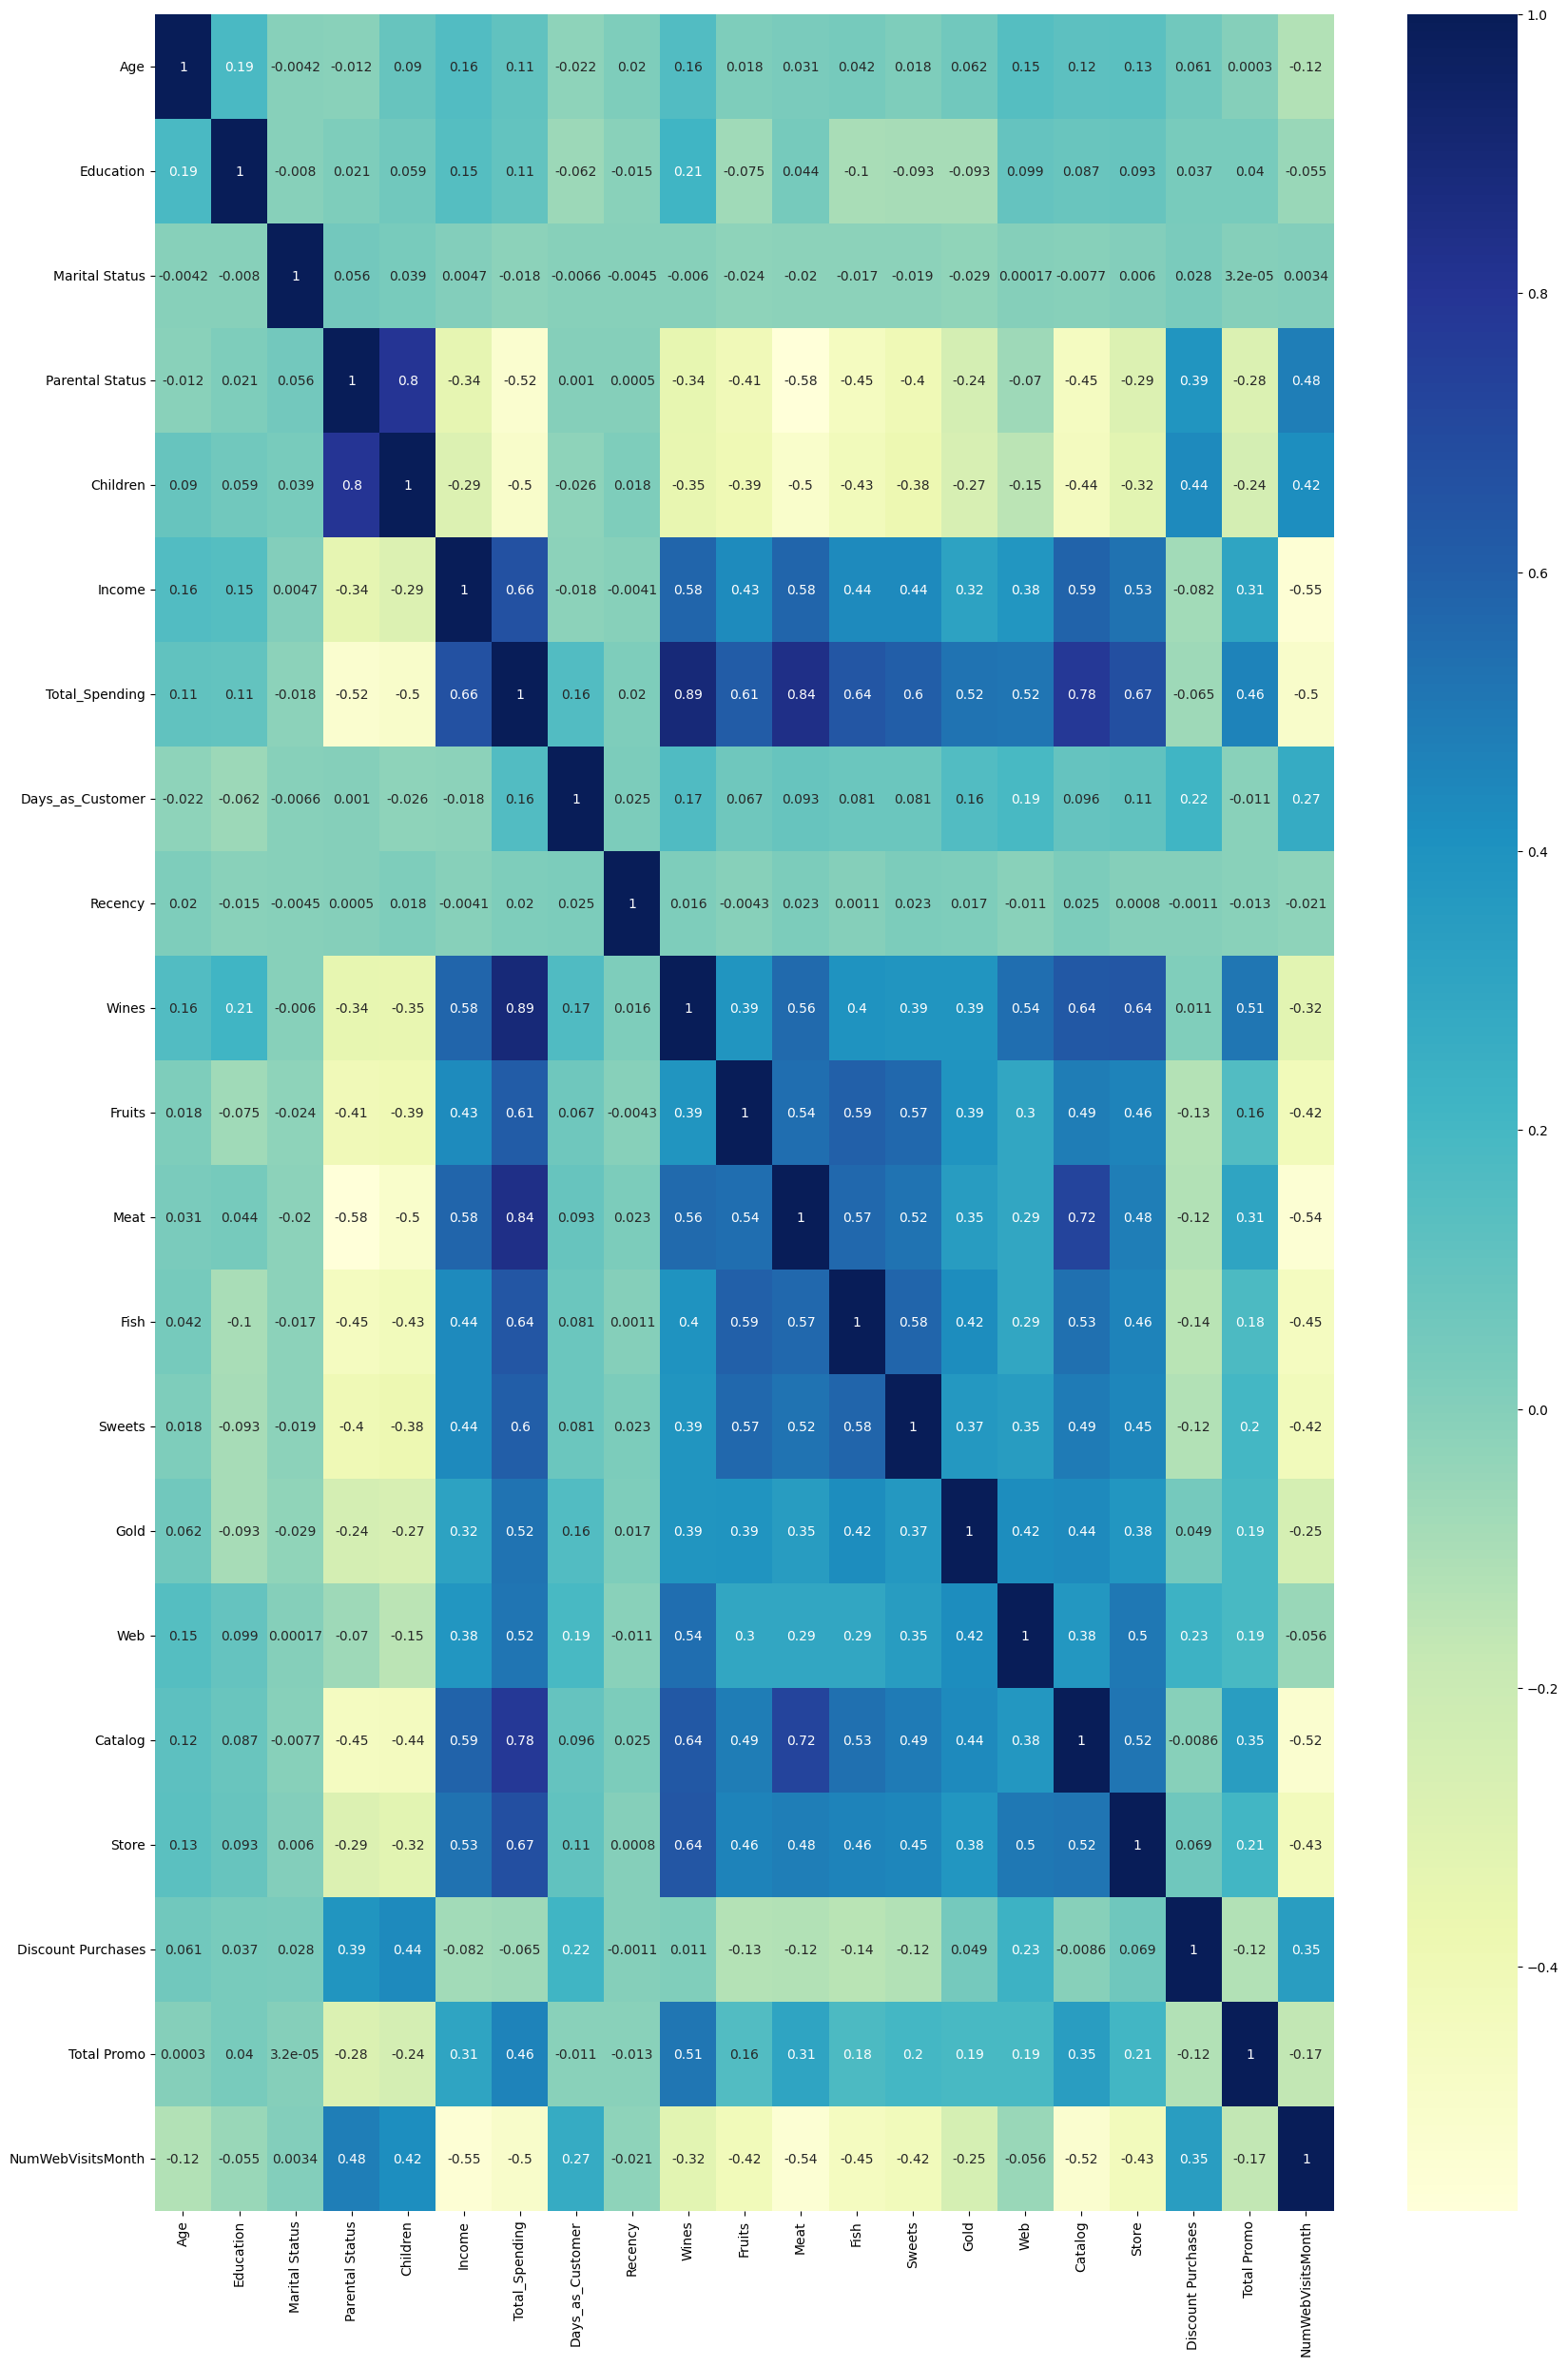

In [102]:
plt.figure(figsize=(20,30))

num_features=numeric_features.copy()

sns.heatmap(df[num_features].corr(),annot=True,cmap='YlGnBu')
plt.show()

In [103]:
#Checking null values
df.isnull().sum()

Age                   0
Education             0
Marital Status        0
Parental Status       0
Children              0
Income                0
Total_Spending        0
Days_as_Customer      0
Recency               0
Wines                 0
Fruits                0
Meat                  0
Fish                  0
Sweets                0
Gold                  0
Web                   0
Catalog               0
Store                 0
Discount Purchases    0
Total Promo           0
NumWebVisitsMonth     0
dtype: int64

## Initial Analysis Report

* **There are missing values in the Income column.**
* **The ID column can be deleted because each row has unique values.**
* **There is no such target feature, so we can do clustering (unlablled data).**


## 4. Visualization

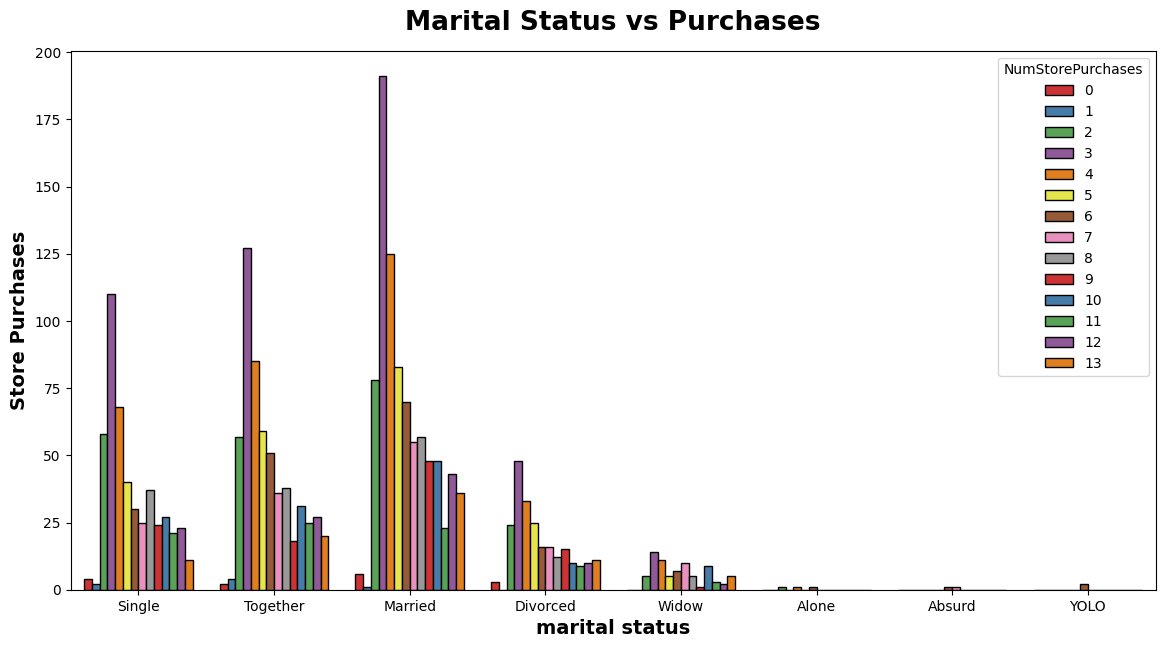

In [109]:
#1
plt.subplots(figsize=(14,7))
sns.countplot(x='Marital_Status',hue='NumStorePurchases',data=df1,ec='black',palette='Set1')
plt.title('Marital Status vs Purchases',weight='bold',fontsize=19,pad=15)
plt.xlabel('marital status',weight='bold',fontsize=14)
plt.ylabel('Store Purchases',weight='bold',fontsize=14)
plt.show()

My findings:

• Married customers represent the largest group in the dataset and therefore account for the highest number of store purchases.

• Customers who are Single or Together also show a significant number of store purchases.

• Categories such as Divorced, Widow, Alone, Absurd, and YOLO have very few customers, which results in fewer store purchases.

• Overall, store purchase behavior appears to be influenced more by the number of customers in each marital status group rather than marital status itself.

Most customers typically make around 3–5 store purchases.

In [110]:
# Now finding the old and the latest/last customer enrollment date in our dataset
dates=[]
for i in raw_df['Dt_Customer']:
  i=i.date()
  dates.append(i)
print(f"Newest/latest customer enrollment date is {max(dates)}")
print(f"Oldest customer enrollment date is {min(dates)}")

Newest/latest customer enrollment date is 2014-06-29
Oldest customer enrollment date is 2012-07-30


In [111]:
df.head()

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
0,68,2,0,0,0,58138.0,1617,4933,58,635,88,546,172,88,88,8,10,4,3,0,7
1,71,2,0,1,2,46344.0,27,4383,38,11,1,6,2,1,6,1,1,2,2,0,5
2,60,2,1,0,0,71613.0,776,4582,26,426,49,127,111,21,42,8,2,10,1,0,4
3,41,2,1,1,1,26646.0,53,4409,26,11,4,20,10,3,5,2,0,4,2,0,6
4,44,4,1,1,1,58293.0,422,4431,94,173,43,118,46,27,15,5,3,6,5,0,5


In [116]:
df.tail()

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
2235,58,2,1,1,1,61223.0,1341,4651,46,709,43,182,42,118,247,9,3,4,2,0,5
2236,79,4,1,1,3,64014.0,444,4289,56,406,0,30,0,0,8,8,2,5,7,1,7
2237,44,2,0,0,0,56981.0,1241,4425,91,908,48,217,32,12,24,2,3,13,1,1,6
2238,69,3,1,1,1,69245.0,843,4426,8,428,30,214,80,30,61,6,5,10,2,0,3
2239,71,4,1,1,2,52869.0,172,4892,40,84,3,61,2,1,21,3,1,4,3,0,7


In [112]:
#setting plotting options

sns.set_style("white")
sns.set(rc={"axes.facecolor":"#cce0ff","figure.facecolor":"#cce0ff"})
sns.set_context("poster",font_scale = .7)


## Customer age distribution plot

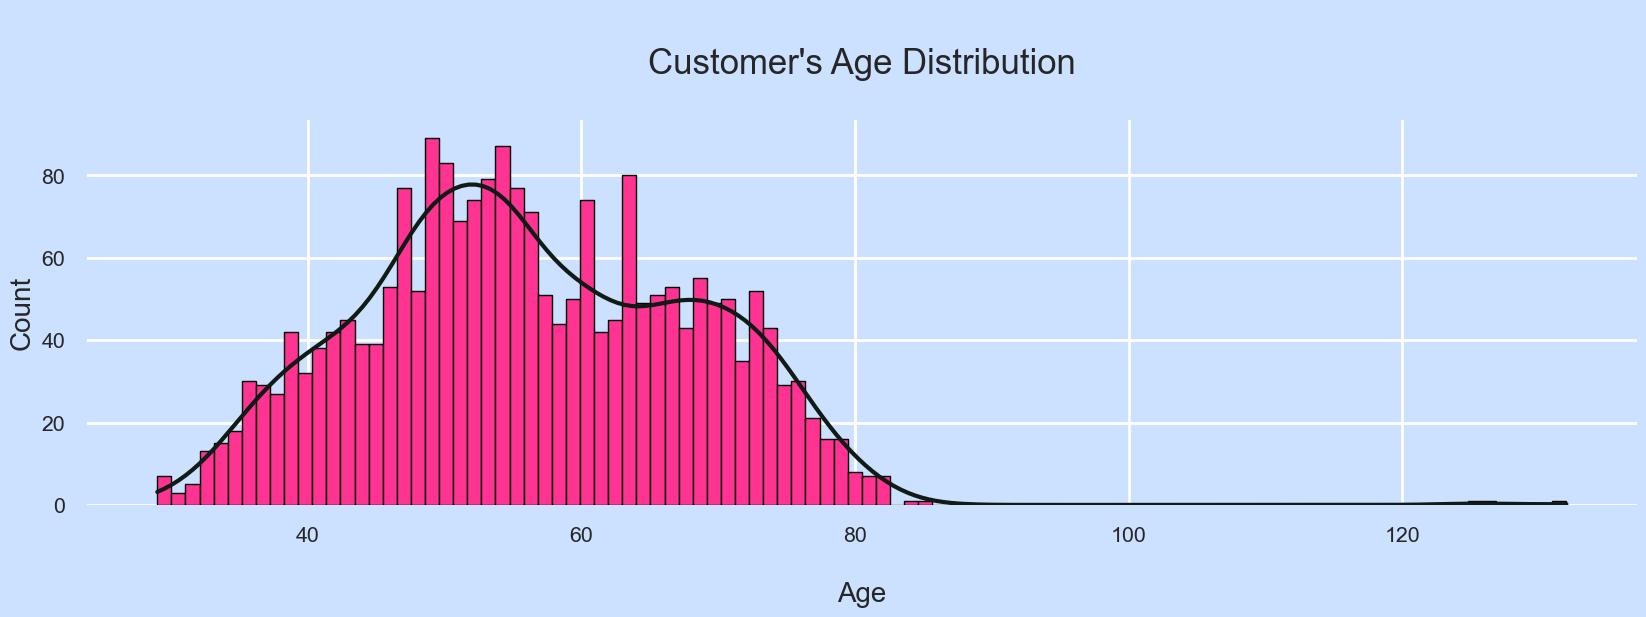

In [114]:

plt.subplots(figsize=(20, 5))
plt.title("Let's have a look on the distribution of customer's age :", weight="bold",fontsize=20, pad=20)

p = sns.histplot(df["Age"],color="#ff3392",kde=True,bins=100,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.set_title("\nCustomer's Age Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAge",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()

Findings:

• The age distribution of customers appears approximately normal, with most customers falling between 40 and 70 years old.

• The peak customer age group lies around 50–60 years, indicating that middle-aged individuals represent the primary customer segment.

• A few extreme age values (above 90 or even above 120) are visible in the distribution. These values are likely data entry errors or unrealistic records.

• Since the majority of customers are below 80 years of age, filtering the dataset to include customers with age less than 90 helps remove outliers and improve data quality.

Target customers ≈ middle-aged people

*it seems we can see most of the customers' age is 80 or less. So we can filter the data by age <90**

Plotting again the customer age distribtuion


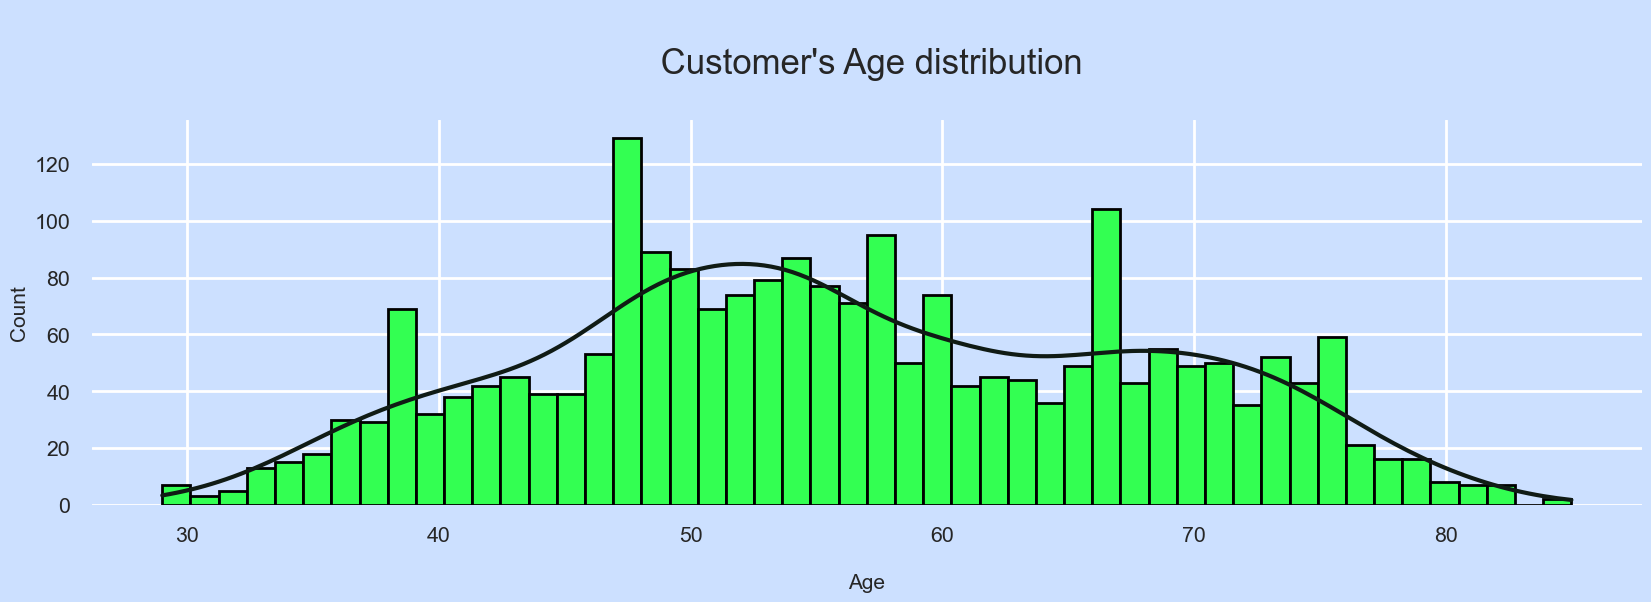

In [120]:
df=df[df['Age']<90]

print(f"Plotting again the customer age distribtuion")

plt.subplots(figsize=(20,5))
p=sns.histplot(df['Age'],color="#33ff52",kde=True,bins=50,alpha=1,edgecolor='black')
p.axes.lines[0].set_color("#101B15")
p.axes.set_title("\n Customer's Age distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=15)
plt.xlabel('\nAge',fontsize=15)
sns.despine(left=True,bottom=True)

plt.show()

**report**
* We can see it's a normal distribution of customer's age.
* Majority of customers fall between 40 and 60 years of age



## Customer's Income-Spending Distribution

Let's have a look on the distribution of customer's income and spending :


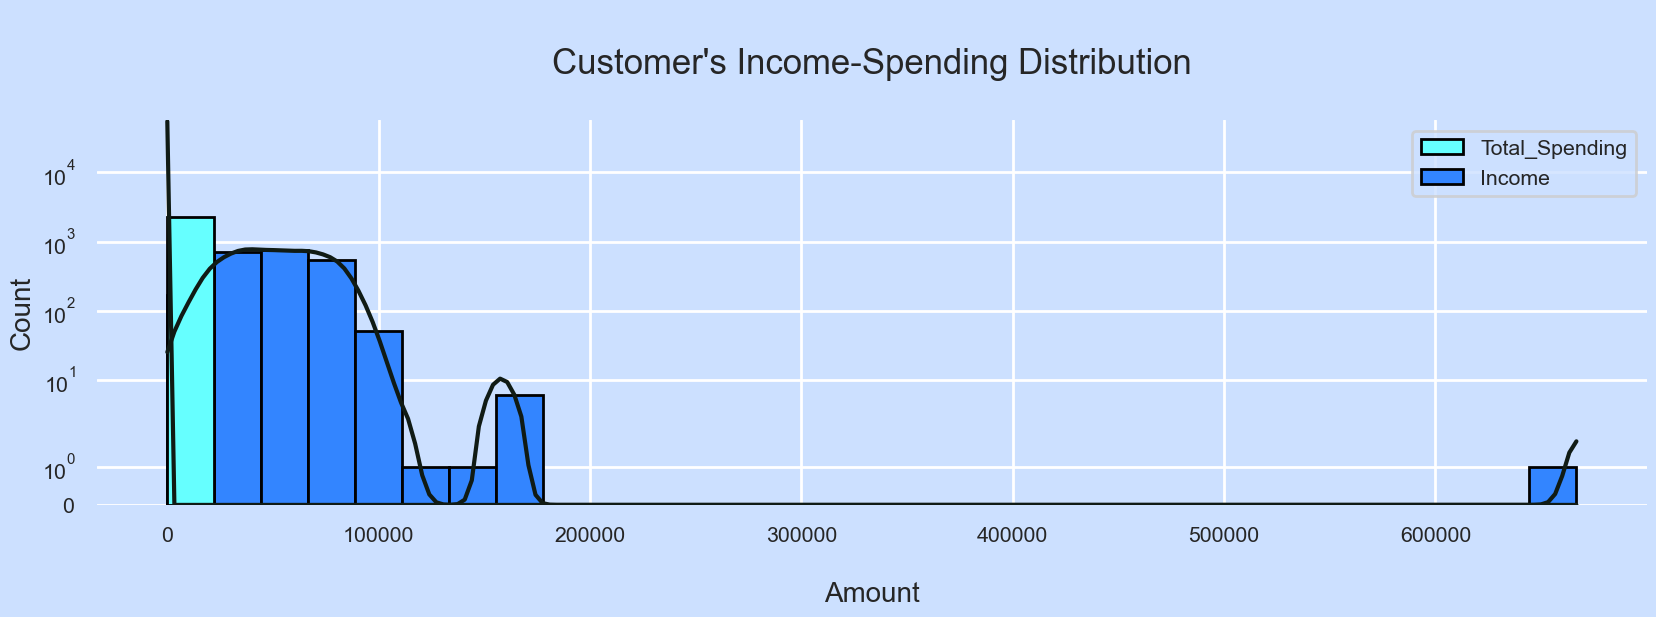

In [121]:
print(f"Let's have a look on the distribution of customer's income and spending :")
plt.subplots(figsize=(20, 5))
p = sns.histplot(df[["Total_Spending","Income"]],palette=["#66ffff","#3385ff"],kde=True,bins=30,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.lines[1].set_color("#101B15")
p.axes.set_yscale("symlog")
p.axes.set_title("\nCustomer's Income-Spending Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAmount",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()

- **Findings**

    - Income Column Does have some outliers which are seen after 60,00,00, so we need filter them out

## Customer's Income-Spending Distribution

Let's have a look again on the distribution of customer's income and spending :


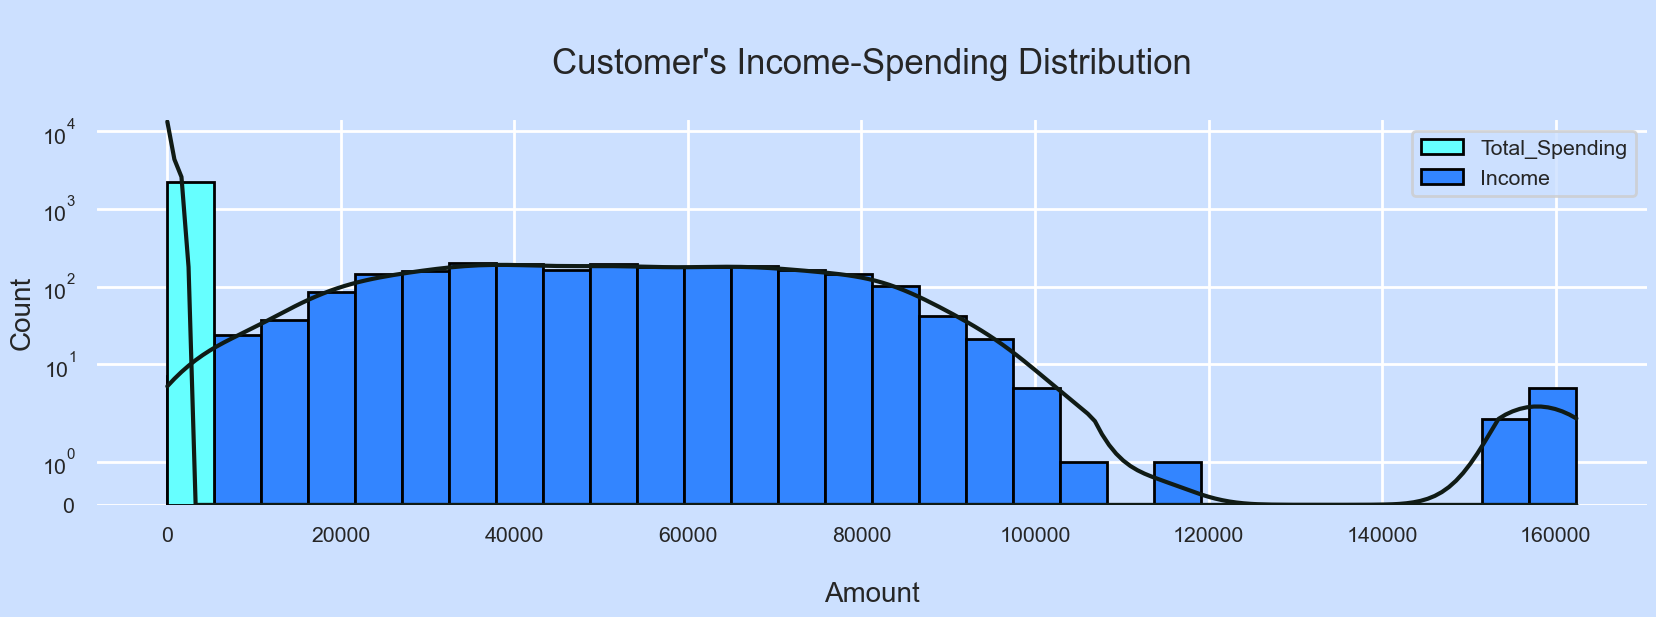

In [122]:
df = df[df["Income"] < 600000]

#now, let's plot again
print(f"Let's have a look again on the distribution of customer's income and spending :")
plt.subplots(figsize=(20, 5))
p = sns.histplot(df[["Total_Spending","Income"]],palette=["#66ffff","#3385ff"],kde=True,bins=30,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.lines[1].set_color("#101B15")
p.axes.set_yscale("symlog")
p.axes.set_title("\nCustomer's Income-Spending Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAmount",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()

**Insights:**

Findings:

• Customer income is mostly concentrated between 20,000 and 80,000.

• A few extreme income values (above 600,000) were identified as outliers and removed to improve data quality.

• Customer spending is significantly lower than their income, indicating that customers typically spend only a small portion of their income on the company's products.

## Customer's Education Level plot (pie)

 the customer's education :


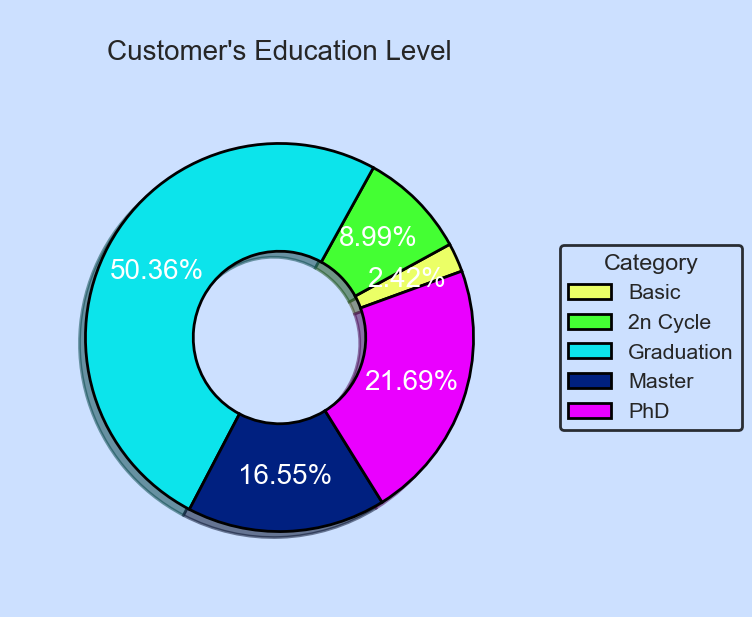

In [131]:
print(f" the customer's education :")
plt.subplots(figsize=(7, 7))

labels = "Basic","2n Cycle", "Graduation", "Master", "PhD"
size = 0.5

wedges, texts, autotexts = plt.pie([df["Education"].value_counts()[0],
                                    df["Education"].value_counts()[1],
                                    df["Education"].value_counts()[2],
                                    df["Education"].value_counts()[3],
                                    df["Education"].value_counts()[4]],
                                    explode = (0,0,0,0,0),
                                    textprops=dict(size= 20, color= "white"),
                                    autopct="%.2f%%", 
                                    pctdistance = 0.72,
                                    radius=.9, 
                                    colors = ["#ebff66","#44ff33","#0ce4eb","#002080","#ea00ff"],
                                    shadow = True,
                                    wedgeprops=dict(width = size, edgecolor = "black",#creates a hole  in center 
                                    linewidth = 2),
                                    startangle = 20)

plt.legend(wedges, labels, title="Category",loc="center left",bbox_to_anchor=(1, 0, 0.5, 1), edgecolor = "black")
plt.title("\nCustomer's Education Level",fontsize=20)
plt.show()

## Education Level-wise Spending Distribution

Let's have a look on the distribution of customer's income and spending on basis of education level :


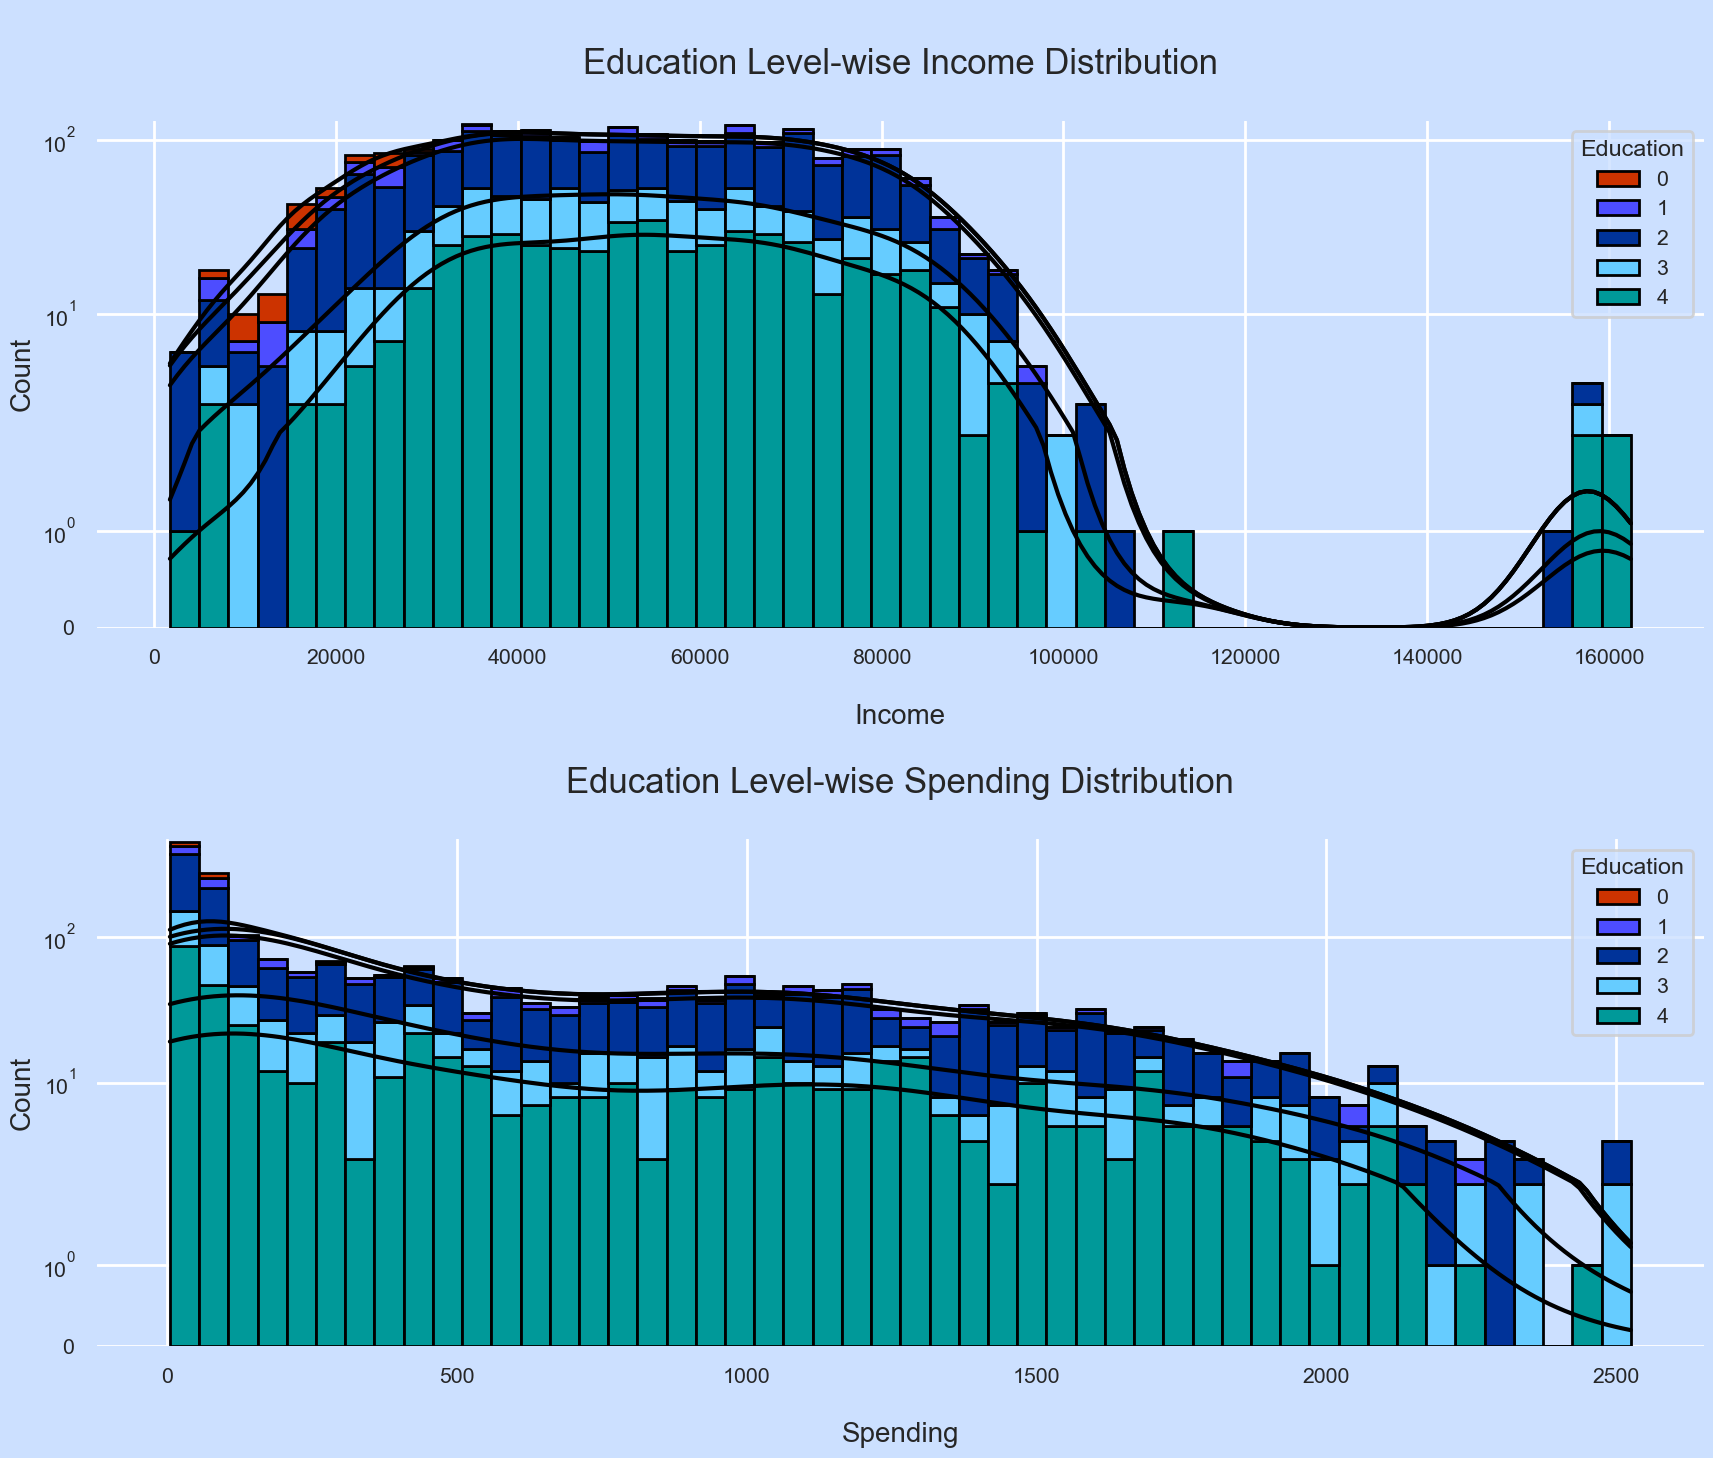

In [127]:
print(f"Let's have a look on the distribution of customer's income and spending on basis of education level :")

_, axes = plt.subplots(2,1,figsize=(20,16),sharex=False)
plt.tight_layout(pad=7.0)

colors = ["#cc2900","#0000ff","#66ffff", "#009999","#99ff66"]
colors2 = ["#cc3300","#4d4dff","#003399","#66ccff","#009999"]
sns.histplot(data=df,x="Income",hue="Education",multiple="stack",palette=colors2,ax=axes[0],kde=True,bins=50,alpha=1,fill=True,edgecolor="black")
axes[0].lines[0].set_color("000000")
axes[0].lines[1].set_color("000000")
axes[0].lines[2].set_color("000000")
axes[0].lines[3].set_color("000000")
axes[0].lines[4].set_color("000000")

axes[0].set_yscale("symlog")
axes[0].set_title("\nEducation Level-wise Income Distribution\n",fontsize=25)
axes[0].set_ylabel("Count",fontsize=20)
axes[0].set_xlabel("\nIncome",fontsize=20)

sns.histplot(data=df,x="Total_Spending",hue="Education",multiple="stack",palette=colors2,ax=axes[1],kde=True,bins=50,alpha=1,fill=True,edgecolor="black")
axes[1].lines[0].set_color("000000")
axes[1].lines[1].set_color("000000")
axes[1].lines[2].set_color("000000")
axes[1].lines[3].set_color("000000")
axes[1].lines[4].set_color("000000")
axes[1].set_yscale("symlog")
axes[1].set_title("\nEducation Level-wise Spending Distribution\n",fontsize=25)
axes[1].set_ylabel("Count",fontsize=20)
axes[1].set_xlabel("\nSpending",fontsize=20)

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

- Most of the undergraduate level customer's income range is in between 10000 to 80000 and spending in between 0 to 1400.
- Most of the graduate level customer's income range is in between 20000 to 85000 and spending in between 0 to 2000.
- Most of the postgraduate level customer's income range is in between 30000 to 80000 and spending in between 0 to 2000.

### Customer's Children Count

The distribution of customer's children :


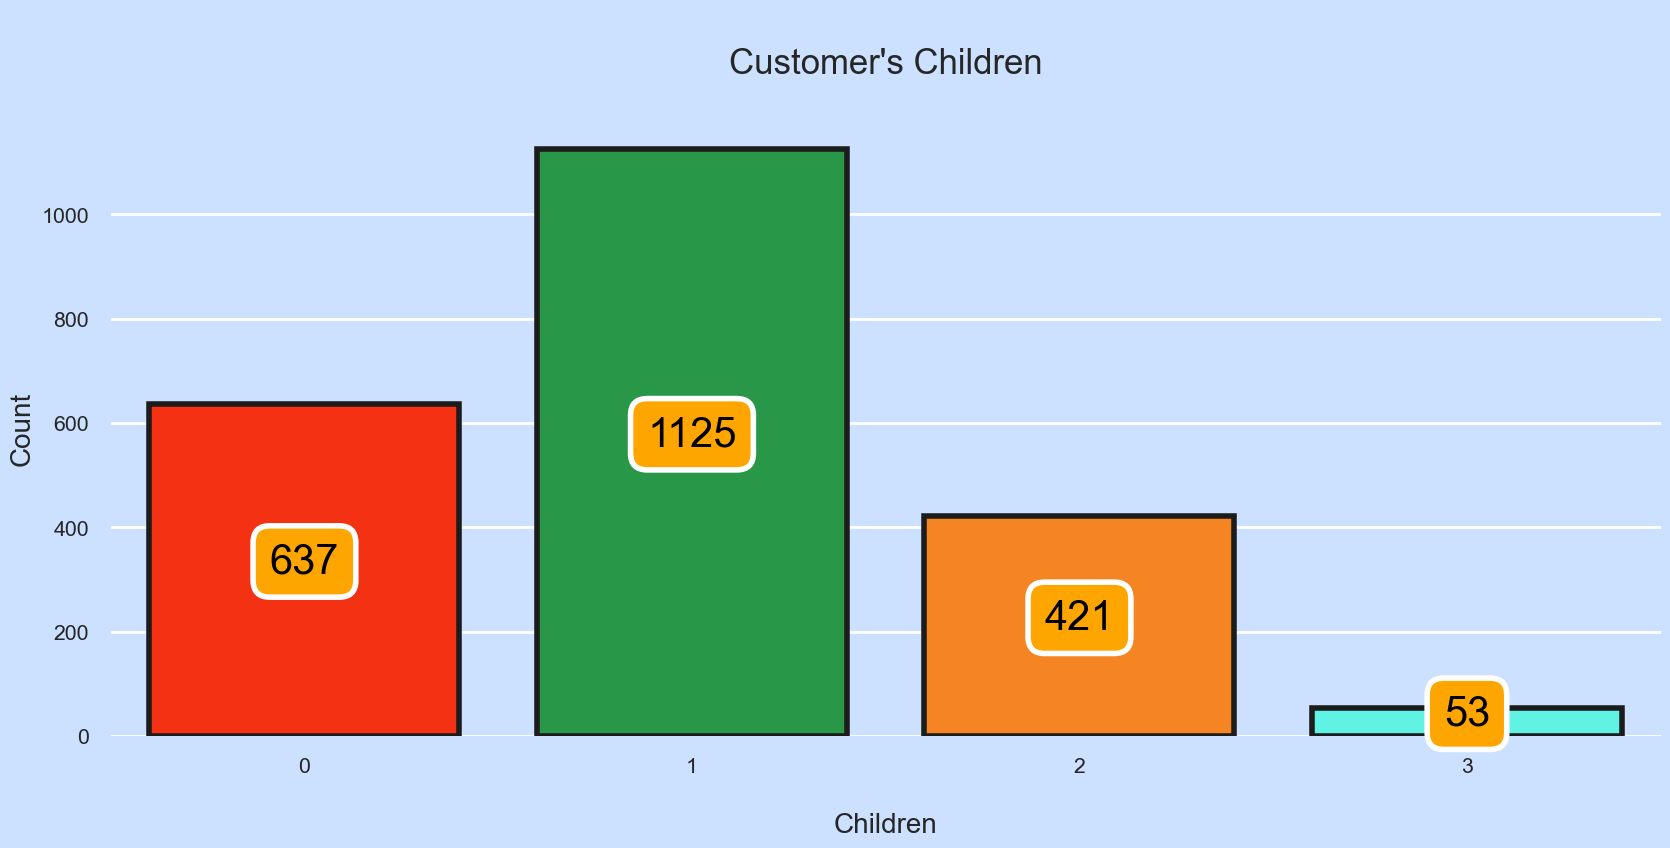

In [130]:
print(f"The distribution of customer's children :")
plt.subplots(figsize=(20, 8))
p = sns.countplot(x=df["Children"],palette=["#F43113","#289848", "#F58522","#60F3E4"], saturation=1,edgecolor = "#1c1c1c", linewidth = 4)
p.axes.set_yscale("linear")
p.axes.set_title("\nCustomer's Children\n",fontsize=25)
p.axes.set_ylabel("Count",fontsize=20)
p.axes.set_xlabel("\nChildren",fontsize=20)
p.axes.set_xticklabels(p.get_xticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.4, "facecolor": "orange", "edgecolor": "white", "linewidth" : 4, "alpha": 1})


sns.despine(left=True, bottom=True)
plt.show()

**Foindings:**

- 637 customers have no child.
- Most of the customers have one child.
- 421 customers have two child.
- 53 customers have three child.

Most customers are graduates with middle income levels
and moderate spending behaviour.

## Final report
- We have seen that this dataset has outliers in Wines, Fruits, Meat, Fish, Sweets, Gold, Age, Total_Spending columns
and multicollinearity in Total_Spending,Wines,Fruits,Meat,Fish,Sweets,Gold columns. So we have to handle those in feature engineering steps.

- We have dropped the ID column as it is not going to participate in any model building task
- The column Z_CostContact, Z_Revenue does have constant values. As this columns does not have any varience, we have dropped this column

- There are some columns which individually does not have such meaning, so in feature engineering we'll retrieve new columns. 